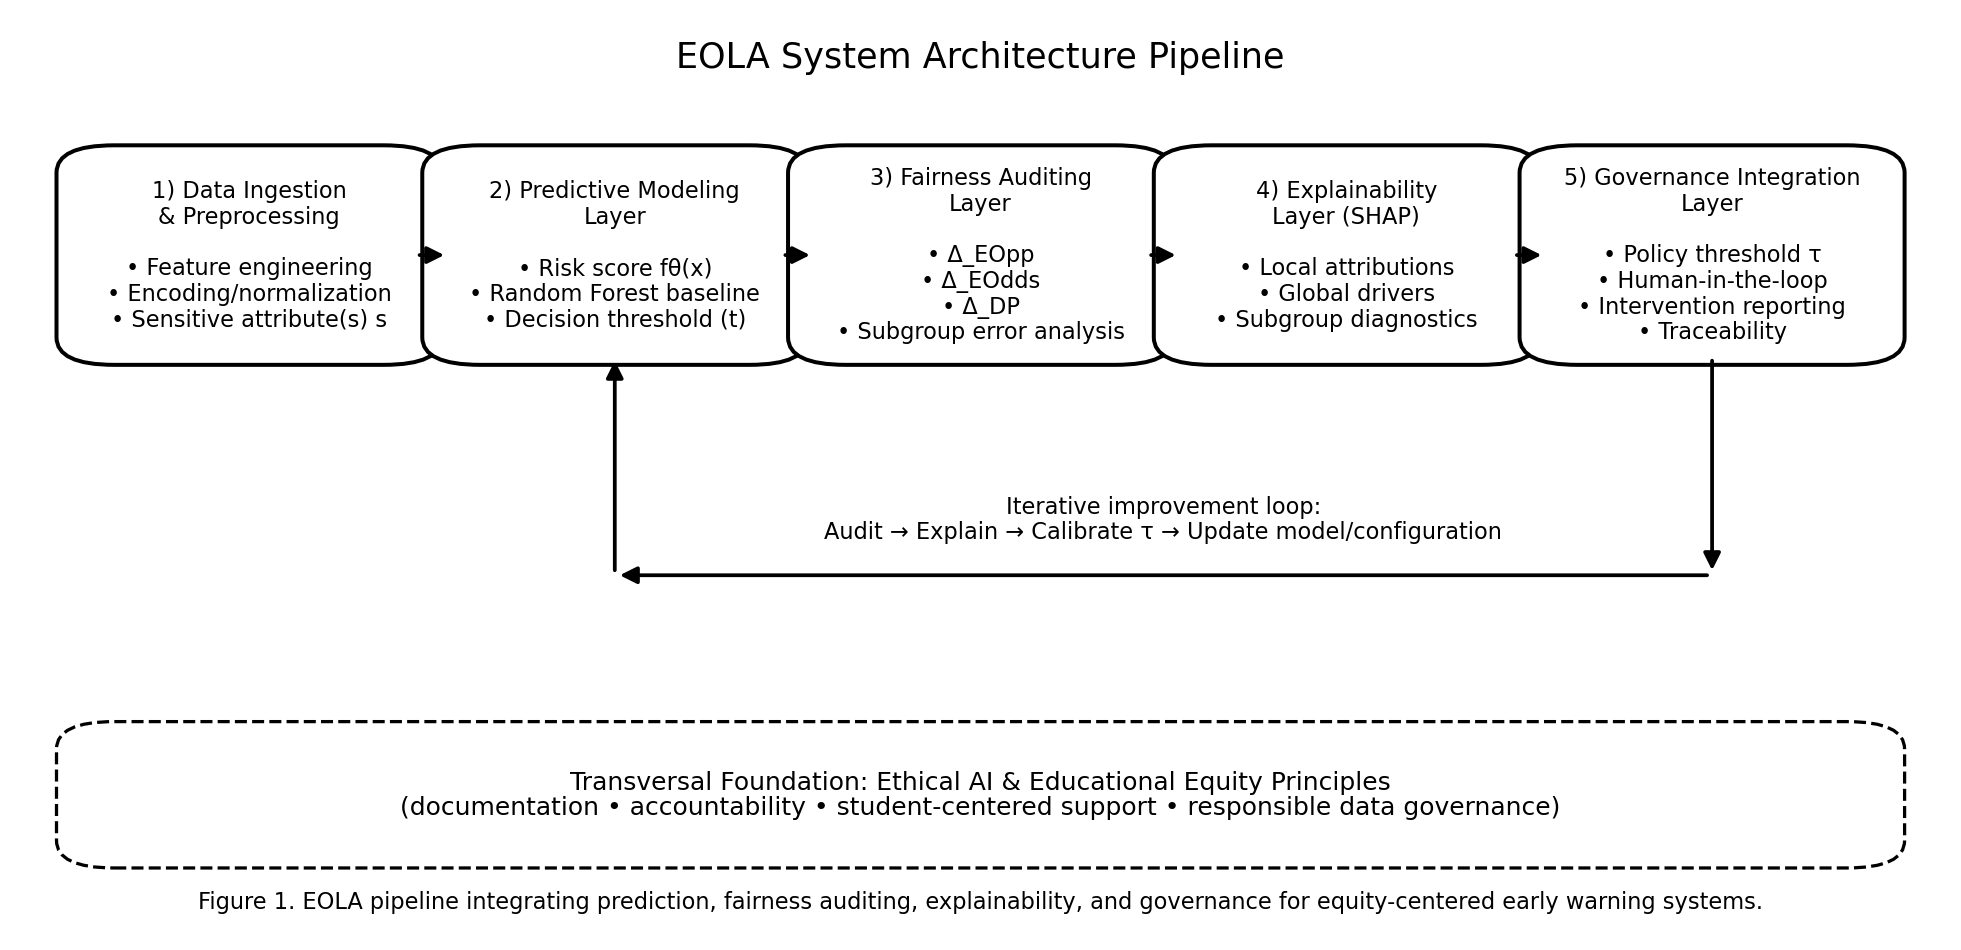

Saved: Figure 1_EOLA_System_Architecture_Pipeline.png
Saved: Figure 1_EOLA_System_Architecture_Pipeline.pdf


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, x, y, w, h, text, fontsize=9, lw=1.6, linespacing=1.15):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=lw,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(
        x + w/2, y + h/2, text,
        ha="center", va="center",
        fontsize=fontsize,
        wrap=True,
        linespacing=linespacing
    )
    return box

def add_arrow(ax, x1, y1, x2, y2, lw=1.5):
    arr = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=lw,
        color="black"
    )
    ax.add_patch(arr)

def auto_font(text, base=9, min_f=7):
    n_lines = text.count("\n") + 1
    n_chars = len(text)
    f = base
    if n_lines >= 10 or n_chars >= 170:
        f = base - 1
    if n_lines >= 12 or n_chars >= 220:
        f = base - 2
    return max(min_f, f)

def plot_eola_pipeline(save_prefix="Figure 1_EOLA_System_Architecture_Pipeline"):
    fig = plt.figure(figsize=(13.8, 6.6), dpi=180)
    ax = plt.gca()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Title
    ax.text(
        0.5, 0.975,
        "EOLA System Architecture Pipeline",
        ha="center", va="top",
        fontsize=14
    )

    left_margin = 0.04
    right_margin = 0.04
    gap = 0.03
    n_boxes = 5

    total_gap = gap * (n_boxes - 1)
    w = (1 - left_margin - right_margin - total_gap) / n_boxes
    h = 0.20
    y = 0.64

    xs = [left_margin + i * (w + gap) for i in range(n_boxes)]

    t1 = (
        "1) Data Ingestion\n& Preprocessing\n\n"
        "• Feature engineering\n"
        "• Encoding/normalization\n"
        "• Sensitive attribute(s) s"
    )
    t2 = (
        "2) Predictive Modeling\nLayer\n\n"
        "• Risk score fθ(x)\n"
        "• Random Forest baseline\n"
        "• Decision threshold (t)"
    )
    t3 = (
        "3) Fairness Auditing\nLayer\n\n"
        "• Δ_EOpp\n"
        "• Δ_EOdds\n"
        "• Δ_DP\n"
        "• Subgroup error analysis"
    )
    t4 = (
        "4) Explainability\nLayer (SHAP)\n\n"
        "• Local attributions\n"
        "• Global drivers\n"
        "• Subgroup diagnostics"
    )
    t5 = (
        "5) Governance Integration\nLayer\n\n"
        "• Policy threshold τ\n"
        "• Human-in-the-loop\n"
        "• Intervention reporting\n"
        "• Traceability"
    )

    add_box(ax, xs[0], y, w, h, t1, fontsize=auto_font(t1))
    add_box(ax, xs[1], y, w, h, t2, fontsize=auto_font(t2))
    add_box(ax, xs[2], y, w, h, t3, fontsize=auto_font(t3))
    add_box(ax, xs[3], y, w, h, t4, fontsize=auto_font(t4))
    add_box(ax, xs[4], y, w, h, t5, fontsize=auto_font(t5))

    for i in range(n_boxes - 1):
        x1 = xs[i] + w
        x2 = xs[i+1]
        y_mid = y + h/2
        add_arrow(ax, x1 + 0.006, y_mid, x2 - 0.006, y_mid)

    loop_y = 0.34
    add_arrow(ax, xs[4] + w/2, y - 0.01, xs[4] + w/2, loop_y + 0.05)
    add_arrow(ax, xs[4] + w/2, loop_y + 0.05, xs[1] + w/2, loop_y + 0.05)
    add_arrow(ax, xs[1] + w/2, loop_y + 0.05, xs[1] + w/2, y - 0.01)

    ax.text(
        (xs[1] + xs[4] + w) / 2,
        loop_y + 0.085,
        "Iterative improvement loop:\nAudit → Explain → Calibrate τ → Update model/configuration",
        ha="center", va="bottom",
        fontsize=9,
        linespacing=1.1
    )

    foundation = FancyBboxPatch(
        (0.04, 0.09), 0.92, 0.12,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1.3,
        facecolor="white",
        edgecolor="black",
        linestyle="--"
    )
    ax.add_patch(foundation)
    ax.text(
        0.5, 0.15,
        "Transversal Foundation: Ethical AI & Educational Equity Principles\n"
        "(documentation • accountability • student-centered support • responsible data governance)",
        ha="center", va="center",
        fontsize=10,
        linespacing=1.1
    )
    ax.text(
        0.5, 0.02,
        "Figure 1. EOLA pipeline integrating prediction, fairness auditing, explainability, and governance for equity-centered early warning systems.",
        ha="center", va="bottom",
        fontsize=9
    )
    png_path = f"{save_prefix}.png"
    pdf_path = f"{save_prefix}.pdf"
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print("Saved:", png_path)
    print("Saved:", pdf_path)

# --- Run ---
plot_eola_pipeline()

In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

SEED = 42
OUTDIR = "outputs"
os.makedirs(OUTDIR, exist_ok=True)

def generate_educational_data(n_samples=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    ses = rng.binomial(1, 0.7, n_samples)  # 0: Low, 1: High
    study_hours = rng.normal(10, 3, n_samples)
    forum_participation = rng.normal(5, 2, n_samples)

    success_score = (0.4 * study_hours + 0.3 * forum_participation +
                     0.2 * ses + rng.normal(0, 1, n_samples))
    threshold = np.median(success_score)
    y_success = (success_score > threshold).astype(int)  # 1=success

    return pd.DataFrame({
        "Study_Hours": study_hours,
        "Forum_Participation": forum_participation,
        "SES_Protected_Attribute": ses,
        "Actual_Outcome": y_success
    })

# Data
data = generate_educational_data(n_samples=1000, seed=SEED)
X = data.drop(columns=["Actual_Outcome"])
y = data["Actual_Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train, y_train)

print("Generating SHAP summary plot...")

try:
    explainer = shap.TreeExplainer(model)
    shap_exp = explainer(X_test)

    vals = shap_exp.values
    if vals.ndim == 3:
        shap_vals = vals[:, :, 1]
    else:
        shap_vals = vals

    plt.figure(figsize=(10, 6), dpi=180)
    shap.summary_plot(shap_vals, X_test, show=False)
except Exception:
    # Fallback to legacy API
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values[:, :, 1] if getattr(shap_values, "ndim", 0) == 3 else shap_values

    plt.figure(figsize=(10, 6), dpi=180)
    shap.summary_plot(shap_vals, X_test, show=False)

plt.title("EOLA Framework: XAI Audit of Academic Risk Factors", fontsize=14, pad=18)
plt.xlabel("SHAP value (impact on model output)", fontsize=12)
plt.tight_layout()

fig_path = os.path.join(OUTDIR, "Figure2_EOLA_XAI_Audit.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close()

cfg = {
    "seed": SEED,
    "n_samples": int(len(data)),
    "test_size": 0.3,
    "model": {"type": "RandomForestClassifier", "n_estimators": 100, "random_state": SEED},
    "target": "Actual_Outcome (1=success in this script)"
}
with open(os.path.join(OUTDIR, "run_config.json"), "w") as f:
    json.dump(cfg, f, indent=2)

print(f"Saved: {fig_path}")
print(f"Saved: {os.path.join(OUTDIR, 'run_config.json')}")

Generating SHAP summary plot...
Saved: outputs/Figure2_EOLA_XAI_Audit.png
Saved: outputs/run_config.json


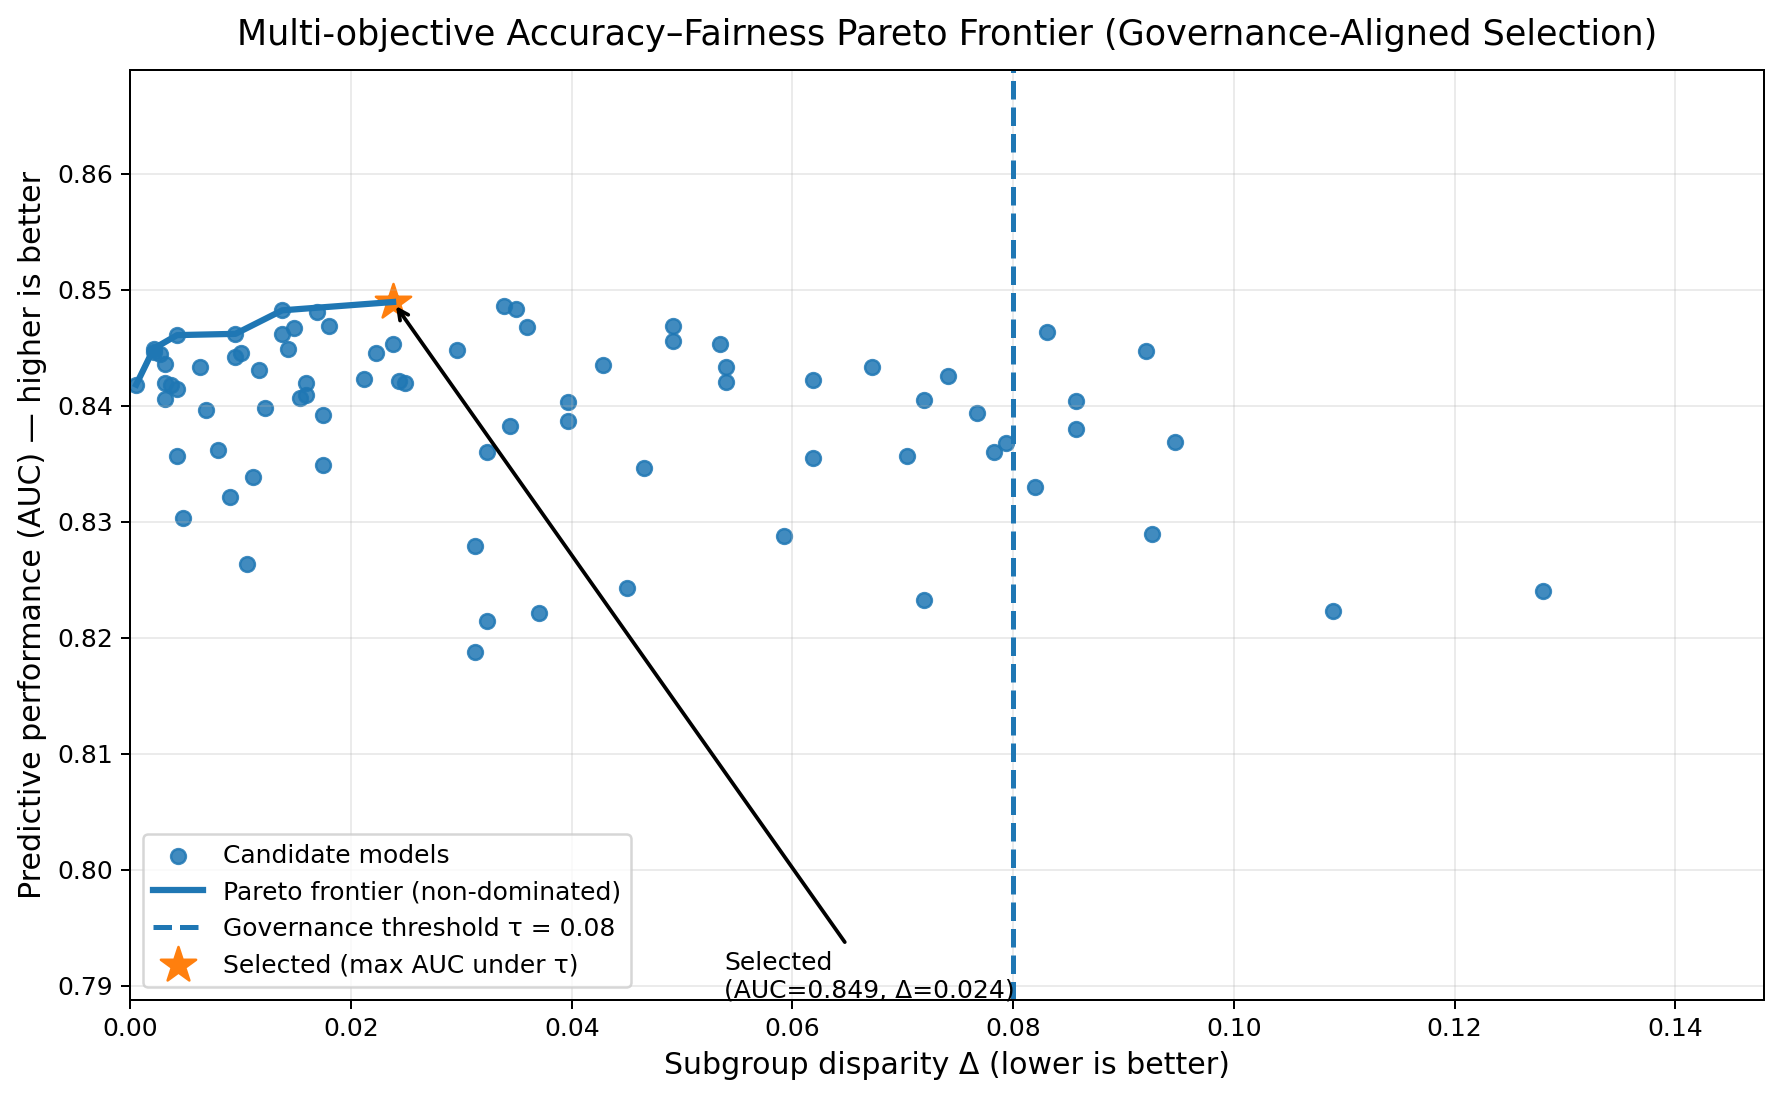

Saved: outputs/Figure3_Pareto_Accuracy_Fairness_Governance.png
Saved: outputs/Figure3_Pareto_Accuracy_Fairness_Governance.pdf

Selected model details:
AUC: 0.8489
Δ  : 0.0238
Decision threshold: 0.736
Hyperparams: {'n_estimators': 237, 'max_depth': 5, 'min_samples_leaf': 3, 'max_features': None}


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# ----------------------------
# 1) Synthetic educational data generator (with structural bias)
# ----------------------------
def generate_educational_data(n=2500, seed=42):
    rng = np.random.default_rng(seed)

    # Protected attribute (e.g., SES): 0 low, 1 high
    s = rng.binomial(1, 0.7, n)

    # Features
    study_hours = rng.normal(10, 3, n)
    forum_participation = rng.normal(5, 2, n)

    # Structural bias: SES affects latent success probability
    latent = (
        0.45 * study_hours +
        0.35 * forum_participation +
        0.35 * s +                 # <-- bias term
        rng.normal(0, 1.2, n)
    )

    y = (latent > np.median(latent)).astype(int)

    X = np.column_stack([study_hours, forum_participation, s])
    feature_names = ["Study_Hours", "Forum_Participation", "SES_Protected_Attribute"]
    return X, y, s, feature_names


# ----------------------------
# 2) Fairness disparity metric Δ (max inter-group TPR gap; Equal Opportunity)
# ----------------------------
def tpr(y_true, y_pred):
    # True Positive Rate = TP / (TP + FN)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def delta_eopp(y_true, y_pred, s):
    # Δ_EOpp = max_{a,b} |TPR_a - TPR_b|
    groups = np.unique(s)
    tprs = []
    for g in groups:
        mask = (s == g)
        tprs.append(tpr(y_true[mask], y_pred[mask]))
    return float(np.max(tprs) - np.min(tprs))


# ----------------------------
# 3) Build candidate models (vary RF hyperparams + decision threshold)
# ----------------------------
def evaluate_candidates(X, y, s, seed=42, n_candidates=60):
    rng = np.random.default_rng(seed)
    X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
        X, y, s, test_size=0.30, random_state=seed, stratify=y
    )

    candidates = []
    for _ in range(n_candidates):
        # Randomly sample hyperparameters
        n_estimators = int(rng.integers(80, 260))
        max_depth = int(rng.integers(2, 14)) if rng.random() < 0.85 else None
        min_samples_leaf = int(rng.integers(1, 9))
        max_features = rng.choice(["sqrt", "log2", None])
        threshold = float(rng.uniform(0.25, 0.75))

        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=int(rng.integers(0, 10_000)),
            n_jobs=-1
        )
        clf.fit(X_train, y_train)

        proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)

        y_hat = (proba >= threshold).astype(int)
        delta = delta_eopp(y_test, y_hat, s_test)

        candidates.append({
            "auc": float(auc),
            "delta": float(delta),
            "threshold": threshold,
            "params": {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "max_features": max_features
            }
        })

    return candidates

# ----------------------------
# 4) Pareto frontier (maximize AUC, minimize Δ)
# ----------------------------
def pareto_frontier(points):
    """
    points: list of dicts with keys: 'auc', 'delta'
    Returns list of indices belonging to non-dominated set (Pareto frontier).
    Dominance: i dominates j if auc_i >= auc_j and delta_i <= delta_j, with at least one strict.
    """
    idxs = list(range(len(points)))
    frontier = []
    for i in idxs:
        dominated = False
        for j in idxs:
            if j == i:
                continue
            ai, di = points[i]["auc"], points[i]["delta"]
            aj, dj = points[j]["auc"], points[j]["delta"]
            if (aj >= ai and dj <= di) and (aj > ai or dj < di):
                dominated = True
                break
        if not dominated:
            frontier.append(i)

    # Sort frontier by delta ascending (so line plot looks nice)
    frontier_sorted = sorted(frontier, key=lambda k: points[k]["delta"])
    return frontier_sorted


# ----------------------------
# 5) Plot: candidates + Pareto + τ line + selected (best AUC under Δ ≤ τ)
# ----------------------------
def plot_accuracy_fairness_tradeoff(candidates, tau=0.08, out_prefix="Figure_Pareto_Accuracy_Fairness_Governance"):
    os.makedirs("outputs", exist_ok=True)

    deltas = np.array([c["delta"] for c in candidates], dtype=float)
    aucs   = np.array([c["auc"]   for c in candidates], dtype=float)

    # Pareto frontier
    pf_idx = pareto_frontier(candidates)
    pf_d   = np.array([candidates[i]["delta"] for i in pf_idx], dtype=float)
    pf_a   = np.array([candidates[i]["auc"]   for i in pf_idx], dtype=float)

    # Governance-compliant: Δ ≤ τ, choose max AUC
    feasible_idx = [i for i, c in enumerate(candidates) if c["delta"] <= tau]
    selected_idx = max(feasible_idx, key=lambda i: candidates[i]["auc"]) if feasible_idx else None

    # --- Plot ---
    fig = plt.figure(figsize=(10, 6.2), dpi=180)
    ax = plt.gca()

    # Candidate models
    ax.scatter(deltas, aucs, s=35, alpha=0.85, label="Candidate models")

    # Pareto frontier line
    if len(pf_idx) >= 2:
        ax.plot(pf_d, pf_a, linewidth=2.5, label="Pareto frontier (non-dominated)")
    else:
        # rare case
        ax.scatter(pf_d, pf_a, s=60, label="Pareto frontier (non-dominated)")

    # τ vertical line
    ax.axvline(tau, linestyle="--", linewidth=2.0, label=f"Governance threshold τ = {tau:.2f}")

    # Selected model
    if selected_idx is not None:
        sx = candidates[selected_idx]["delta"]
        sy = candidates[selected_idx]["auc"]
        ax.scatter([sx], [sy], marker="*", s=220, label="Selected (max AUC under τ)")
        ax.annotate(
            f"Selected\n(AUC={sy:.3f}, Δ={sx:.3f})",
            xy=(sx, sy),
            xytext=(sx + 0.03, sy - 0.06),
            arrowprops=dict(arrowstyle="->", linewidth=1.5),
            fontsize=10
        )

    # Labels/title
    ax.set_title("Multi-objective Accuracy–Fairness Pareto Frontier (Governance-Aligned Selection)", fontsize=14, pad=10)
    ax.set_xlabel("Subgroup disparity Δ (lower is better)", fontsize=12)
    ax.set_ylabel("Predictive performance (AUC) — higher is better", fontsize=12)

    # Clean limits (optional)
    ax.set_xlim(max(0.0, deltas.min() - 0.01), deltas.max() + 0.02)
    ax.set_ylim(max(0.0, aucs.min() - 0.03), min(1.0, aucs.max() + 0.02))

    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower left", frameon=True)

    # Save
    png_path = os.path.join("outputs", f"{out_prefix}.png")
    pdf_path = os.path.join("outputs", f"{out_prefix}.pdf")
    plt.tight_layout()
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print("Saved:", png_path)
    print("Saved:", pdf_path)

    # Return info for paper text if you want
    if selected_idx is not None:
        return candidates[selected_idx], pf_idx
    return None, pf_idx

# ----------------------------
# RUN
# ----------------------------
X, y, s, feature_names = generate_educational_data(n=2500, seed=42)
candidates = evaluate_candidates(X, y, s, seed=42, n_candidates=80)

selected, pf_idx = plot_accuracy_fairness_tradeoff(
    candidates,
    tau=0.08,
    out_prefix="Figure3_Pareto_Accuracy_Fairness_Governance"
)

if selected is not None:
    print("\nSelected model details:")
    print("AUC:", round(selected["auc"], 4))
    print("Δ  :", round(selected["delta"], 4))
    print("Decision threshold:", round(selected["threshold"], 3))
    print("Hyperparams:", selected["params"])
else:
    print("\nNo candidate satisfied Δ ≤ τ. Try increasing τ or generating more candidates.")